In [3]:
# Re-load the dataset since the execution state was reset
import pandas as pd

# Recreate the dataset
data = {
    "Store_ID": [412, 430, 435, 449, 456, 458, 459, 467, 471, 473],
    "Apr_2019": [2142331, 2161544, 2373907, 1842443, 2643997, 2328138, 2524201, 2080240, 3428564, 3404378],
    "May_2019": [2154163, 2271499, 2367039, 1852805, 2546181, 2127556, 2498001, 2007813, 3320345, 3147100],
    "Jun_2019": [2404423, 2090516, 2363188, 1819357, 2512604, 2157661, 2389367, 1818026, 3292330, 3184921],
    "Jul_2019": [2688289, 2400847, 2568293, 2105340, 2675319, 2541656, 2629892, 1924131, 3512572, 3388290],
    "Aug_2019": [2754922, 2389861, 2558324, 2089806, 2787039, 2277980, 2644974, 2010389, 3313337, 3232378],
    "Sep_2019": [2774976, 2206933, 2406066, 1920772, 2434907, 2195110, 2238918, 1724246, 3123015, 2817906],
    "Pct_Change_May": [0.55, 5.09, -0.29, 0.56, -3.70, -8.62, -1.04, -3.48, -3.16, -7.56],
    "Pct_Change_Jun": [11.62, -7.97, -0.16, -1.81, -1.32, 1.42, -4.35, -9.45, -0.84, 1.20],
    "Pct_Change_Jul": [11.81, 14.84, 8.68, 15.72, 6.48, 17.80, 10.07, 5.84, 6.69, 6.39],
    "Pct_Change_Aug": [2.48, -0.46, -0.39, -0.74, 4.18, -10.37, 0.57, 4.48, -5.67, -4.60],
    "Pct_Change_Sep": [0.73, -7.65, -5.95, -8.09, -12.63, -3.64, -15.35, -14.23, -5.74, -12.82],
    "Total_Revenue": [14919105, 13521200, 14636818, 11630522, 15600047, 13628102, 14925353, 11564845, 19990163, 19174973]
}

df_stores = pd.DataFrame(data)

# Identify the stores with the most significant positive and negative revenue changes
top_increases = df_stores.loc[df_stores.iloc[:, 7:].max(axis=1).nlargest(5).index]
top_decreases = df_stores.loc[df_stores.iloc[:, 7:].min(axis=1).nsmallest(5).index]

# Combine results for easy viewing
significant_changes = pd.concat([top_increases, top_decreases])

# Display results
print(significant_changes)  # This will display the DataFrame in the terminal



   Store_ID  Apr_2019  May_2019  Jun_2019  Jul_2019  Aug_2019  Sep_2019  \
8       471   3428564   3320345   3292330   3512572   3313337   3123015   
9       473   3404378   3147100   3184921   3388290   3232378   2817906   
4       456   2643997   2546181   2512604   2675319   2787039   2434907   
6       459   2524201   2498001   2389367   2629892   2644974   2238918   
0       412   2142331   2154163   2404423   2688289   2754922   2774976   
6       459   2524201   2498001   2389367   2629892   2644974   2238918   
7       467   2080240   2007813   1818026   1924131   2010389   1724246   
9       473   3404378   3147100   3184921   3388290   3232378   2817906   
4       456   2643997   2546181   2512604   2675319   2787039   2434907   
5       458   2328138   2127556   2157661   2541656   2277980   2195110   

   Pct_Change_May  Pct_Change_Jun  Pct_Change_Jul  Pct_Change_Aug  \
8           -3.16           -0.84            6.69           -5.67   
9           -7.56            1.20   

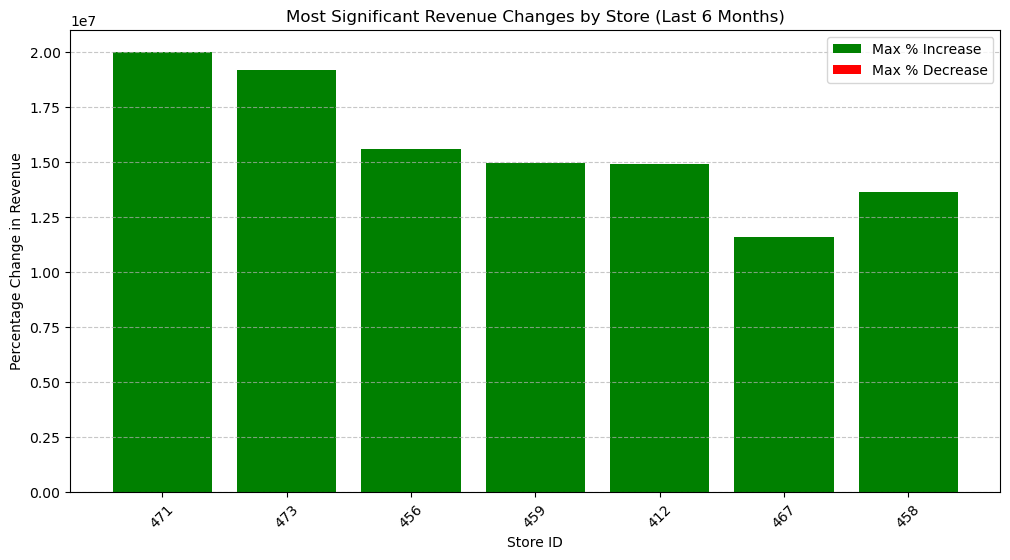

In [5]:
import matplotlib.pyplot as plt

# Plot a bar chart for revenue percentage changes
plt.figure(figsize=(12, 6))
plt.bar(significant_changes["Store_ID"].astype(str), significant_changes.iloc[:, 7:].max(axis=1), color='green', label="Max % Increase")
plt.bar(significant_changes["Store_ID"].astype(str), significant_changes.iloc[:, 7:].min(axis=1), color='red', label="Max % Decrease")

plt.xlabel("Store ID")
plt.ylabel("Percentage Change in Revenue")
plt.title("Most Significant Revenue Changes by Store (Last 6 Months)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the chart
plt.show()


In [7]:
# Create a DataFrame from the provided distinct count data to analyze trends
data_distinct = {
    "Store_ID": [412, 430, 435, 449, 456, 458, 459, 467, 471, 473],
    "Apr_2019": [5044, 5063, 5679, 5030, 5360, 5615, 6464, 5486, 7206, 6585],
    "May_2019": [5163, 5155, 5425, 4934, 5205, 5217, 6052, 5219, 7183, 6383],
    "Jun_2019": [5583, 5103, 5459, 4812, 5341, 5145, 6059, 5181, 7135, 6379],
    "Jul_2019": [5503, 5096, 5564, 5487, 5494, 5460, 6129, 4632, 6032, 6726],
    "Aug_2019": [6278, 5160, 5725, 5324, 5597, 5504, 6676, 5238, 7357, 6524],
    "Sep_2019": [6334, 4879, 5256, 5098, 5164, 5316, 6142, 4943, 7116, 6097],
    "Pct_Change_May": [0.55, 5.09, -0.29, 0.56, -3.70, -8.62, -1.04, -3.48, -3.16, -7.56],
    "Pct_Change_Jun": [11.62, -7.97, -0.16, -1.81, -1.32, 1.42, -4.35, -9.45, -0.84, 1.20],
    "Pct_Change_Jul": [11.81, 14.84, 8.68, 15.72, 6.48, 17.80, 10.07, 5.84, 6.69, 6.39],
    "Pct_Change_Aug": [2.48, -0.46, -0.39, -0.74, 4.18, -10.37, 0.57, 4.48, -5.67, -4.60],
    "Pct_Change_Sep": [0.73, -7.65, -5.95, -8.09, -12.63, -3.64, -15.35, -14.23, -5.74, -12.82],
    "Total_Distinct": [25540, 23477, 24768, 22256, 25083, 24481, 27620, 22407, 31930, 29163]
}

df_distinct = pd.DataFrame(data_distinct)

# Identify the stores with the most significant positive and negative distinct count changes
top_increases_distinct = df_distinct.loc[df_distinct.iloc[:, 7:].max(axis=1).nlargest(5).index]
top_decreases_distinct = df_distinct.loc[df_distinct.iloc[:, 7:].min(axis=1).nsmallest(5).index]

# Combine results for easy viewing
significant_distinct_changes = pd.concat([top_increases_distinct, top_decreases_distinct])

# Display results
print(significant_changes)  # This will display the DataFrame in the terminal


   Store_ID  Apr_2019  May_2019  Jun_2019  Jul_2019  Aug_2019  Sep_2019  \
8       471   3428564   3320345   3292330   3512572   3313337   3123015   
9       473   3404378   3147100   3184921   3388290   3232378   2817906   
4       456   2643997   2546181   2512604   2675319   2787039   2434907   
6       459   2524201   2498001   2389367   2629892   2644974   2238918   
0       412   2142331   2154163   2404423   2688289   2754922   2774976   
6       459   2524201   2498001   2389367   2629892   2644974   2238918   
7       467   2080240   2007813   1818026   1924131   2010389   1724246   
9       473   3404378   3147100   3184921   3388290   3232378   2817906   
4       456   2643997   2546181   2512604   2675319   2787039   2434907   
5       458   2328138   2127556   2157661   2541656   2277980   2195110   

   Pct_Change_May  Pct_Change_Jun  Pct_Change_Jul  Pct_Change_Aug  \
8           -3.16           -0.84            6.69           -5.67   
9           -7.56            1.20   

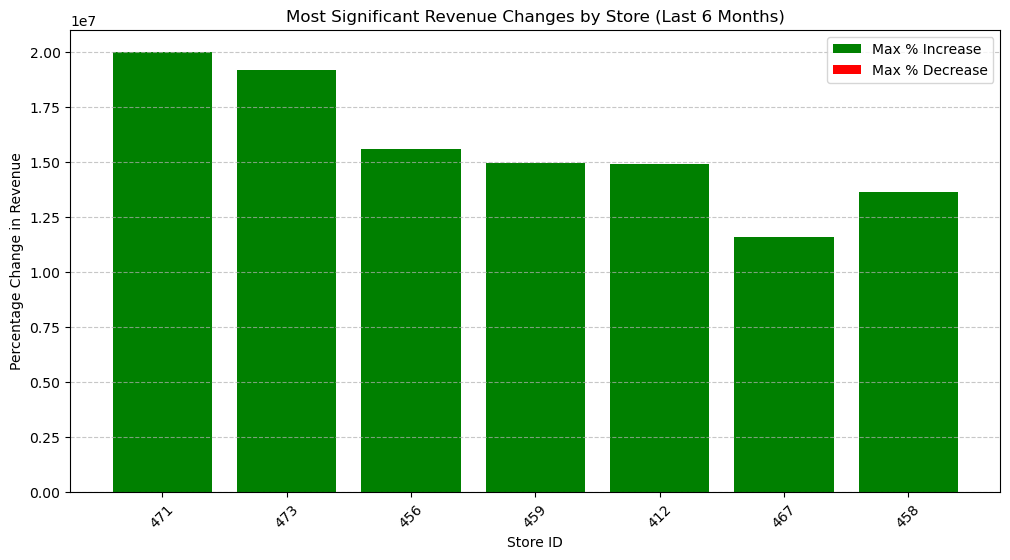

In [9]:
import matplotlib.pyplot as plt

# Plot a bar chart for revenue percentage changes
plt.figure(figsize=(12, 6))
plt.bar(significant_changes["Store_ID"].astype(str), significant_changes.iloc[:, 7:].max(axis=1), color='green', label="Max % Increase")
plt.bar(significant_changes["Store_ID"].astype(str), significant_changes.iloc[:, 7:].min(axis=1), color='red', label="Max % Decrease")

plt.xlabel("Store ID")
plt.ylabel("Percentage Change in Revenue")
plt.title("Most Significant Revenue Changes by Store (Last 6 Months)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the chart
plt.show()


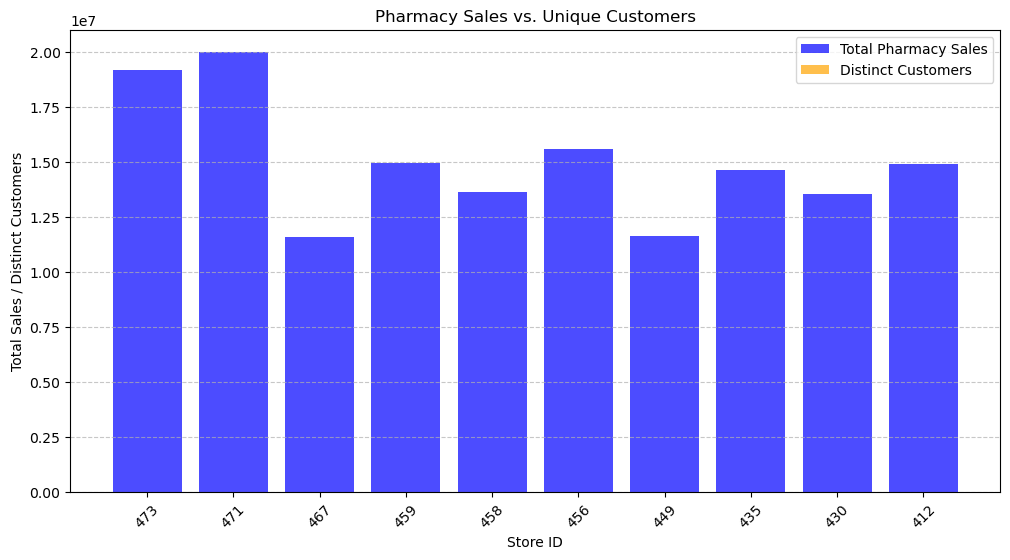

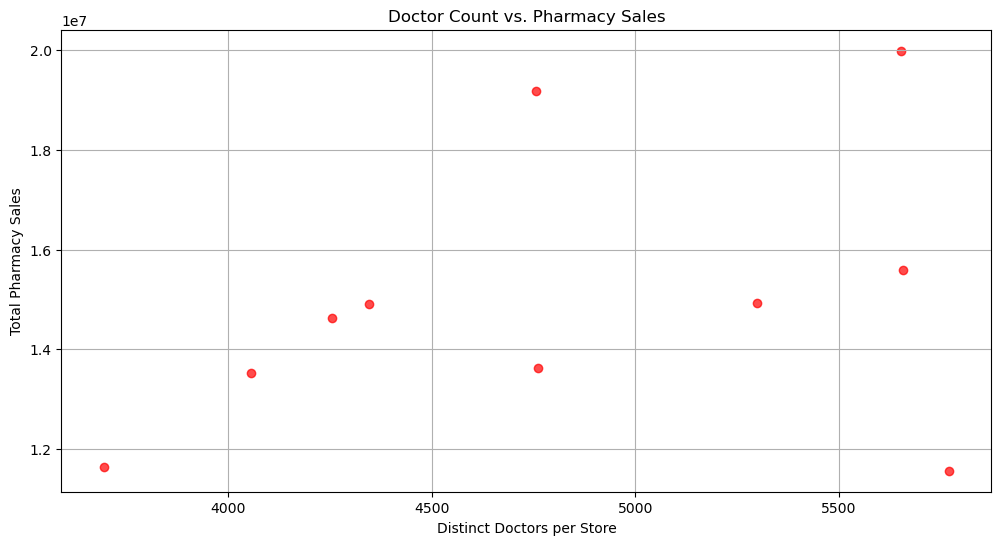

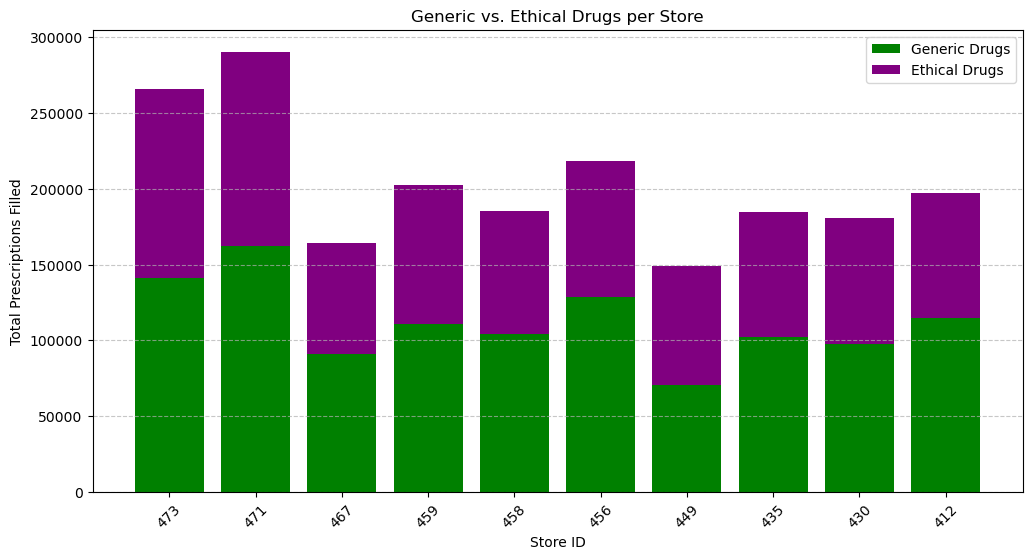

In [11]:
# Re-load the dataset since the execution state was reset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Recreate the dataset with correct columns
data_visualization = {
    "Store_ID": [473, 471, 467, 459, 458, 456, 449, 435, 430, 412],
    "Total_Sales": [19174972.53, 19990162.81, 11564844.97, 14925352.6, 13628102.03, 
                    15600046.89, 11630522.06, 14636818.31, 13521200.36, 14919105.12],
    "Distinct_Customers": [9857, 12499, 11130, 10941, 8984, 9245, 7750, 10395, 8856, 11724],
    "Distinct_Doctors": [4756, 5652, 5771, 5299, 4762, 5657, 3694, 4255, 4056, 4347],
    "Generic_Drugs": [141518, 162627, 90853, 110717, 104178, 128669, 70320, 102559, 97747, 114520],
    "Ethical_Drugs": [124716, 127750, 73223, 92164, 81338, 89757, 79104, 82179, 83115, 82660]
}

df_visualization = pd.DataFrame(data_visualization)

# Bar chart: Pharmacy Sales vs. Unique Customers
plt.figure(figsize=(12, 6))
plt.bar(df_visualization["Store_ID"].astype(str), df_visualization["Total_Sales"], 
        color='blue', alpha=0.7, label="Total Pharmacy Sales")
plt.bar(df_visualization["Store_ID"].astype(str), df_visualization["Distinct_Customers"], 
        color='orange', alpha=0.7, label="Distinct Customers")

plt.xlabel("Store ID")
plt.ylabel("Total Sales / Distinct Customers")
plt.title("Pharmacy Sales vs. Unique Customers")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Scatter Plot: Doctor Count vs. Pharmacy Sales
plt.figure(figsize=(12, 6))
plt.scatter(df_visualization["Distinct_Doctors"], df_visualization["Total_Sales"], 
            color='red', alpha=0.7)
plt.xlabel("Distinct Doctors per Store")
plt.ylabel("Total Pharmacy Sales")
plt.title("Doctor Count vs. Pharmacy Sales")
plt.grid(True)
plt.show()

# Stacked Bar Chart: Generic vs. Ethical Drugs per Store
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_visualization["Store_ID"].astype(str), df_visualization["Generic_Drugs"], 
       color='green', label="Generic Drugs")
ax.bar(df_visualization["Store_ID"].astype(str), df_visualization["Ethical_Drugs"], 
       color='purple', bottom=df_visualization["Generic_Drugs"], label="Ethical Drugs")

ax.set_xlabel("Store ID")
ax.set_ylabel("Total Prescriptions Filled")
ax.set_title("Generic vs. Ethical Drugs per Store")
ax.legend()
ax.set_xticks(range(len(df_visualization["Store_ID"])))
ax.set_xticklabels(df_visualization["Store_ID"].astype(str), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
